In [27]:
import numpy as np
import pandas as pd

from scipy.stats import zscore

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    classification_report, roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Reshape, Conv1D, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression


Models


In [7]:
# 3) Evaluation helper

def evaluate_model(name, y_true, y_pred, y_prob=None):
    print(f"\n===== {name} =====")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1-score :", round(f1_score(y_true, y_pred), 4))
    
    if y_prob is not None:
        print("ROC-AUC  :", round(roc_auc_score(y_true, y_prob), 4))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

Models with the new features 

In [8]:
df_cleaned = pd.read_csv('D:\study\semster 2 year 3\XAI\XAI github\cardiovascular_fe.csv')
df_cleaned.head()

,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE,BMI,PULSE_PRESSURE,MAP,RISK_SCORE,METABOLIC_RISK,AGE_BP_RISK
0,50,2,168,62,110,80,1,1,0,0,1,0,21.967120,30,90.000000,50,2,5500
1,55,1,156,85,140,90,3,1,0,0,1,1,34.927679,50,106.666667,165,4,7700
2,52,1,165,64,130,70,3,1,0,0,0,1,23.507805,60,90.000000,156,4,6760
3,48,2,169,82,150,100,1,1,0,0,1,1,28.710479,50,116.666667,48,2,7200
4,60,1,151,67,120,80,2,2,0,0,0,0,29.384676,40,93.333333,120,4,7200


In [9]:
M = df_cleaned.drop('CARDIO_DISEASE', axis=1)
N = df_cleaned['CARDIO_DISEASE']

In [10]:
from sklearn.model_selection import train_test_split

M_train, M_test, N_train, N_test = train_test_split(
    M, N,
    test_size=0.2,
    random_state=42,
    stratify=N
)

In [11]:

scaler_new = StandardScaler()
M_train_scaled = scaler_new.fit_transform(M_train)
M_test_scaled = scaler_new.transform(M_test)

print("Train scaled shape:", M_train_scaled.shape)
print("Test scaled shape:", M_test_scaled.shape)

Train scaled shape: (50010, 17)
Test scaled shape: (12503, 17)


In [14]:
rfe_estimator = LogisticRegression(
    max_iter=1000,
    random_state=42
)

rfe = RFE(
    estimator=rfe_estimator,
    n_features_to_select=8
)

rfe.fit(M_train_scaled, N_train)

rfe_features = M.columns[rfe.support_].tolist()

print("Selected RFE features:")
for i, feature in enumerate(rfe_features, 1):
    print(f"{i}. {feature}")

M_train_rfe = M_train_scaled[:, rfe.support_]
M_test_rfe = M_test_scaled[:, rfe.support_]

print("\nRFE training shape:", M_train_rfe.shape)
print("RFE testing shape:", M_test_rfe.shape)

Selected RFE features:
1. AGE
2. AP_HIGH
3. AP_LOW
4. CHOLESTEROL
5. PULSE_PRESSURE
6. MAP
7. RISK_SCORE
8. AGE_BP_RISK

RFE training shape: (50010, 8)
RFE testing shape: (12503, 8)


In [15]:
# 7) MLP baseline

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,
    batch_size=256,
    learning_rate_init=0.0005,
    max_iter=150,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42
)

mlp.fit(M_train_rfe, N_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",256
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.0005
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",150
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [16]:
y_train_pred_mlp = mlp.predict(M_train_rfe)
y_test_pred_mlp = mlp.predict(M_test_rfe)

y_train_prob_mlp = mlp.predict_proba(M_train_rfe)[:, 1]
y_test_prob_mlp = mlp.predict_proba(M_test_rfe)[:, 1]

mlp_train_acc = accuracy_score(N_train, y_train_pred_mlp)
mlp_test_acc = accuracy_score(N_test, y_test_pred_mlp)
mlp_train_auc = roc_auc_score(N_train, y_train_prob_mlp)
mlp_test_auc = roc_auc_score(N_test, y_test_prob_mlp)

print("MLP Training Accuracy:", mlp_train_acc)
print("MLP Testing Accuracy:", mlp_test_acc)
print("MLP Training AUC:", mlp_train_auc)
print("MLP Testing AUC:", mlp_test_auc)

print("\nClassification Report - MLP:")
print(classification_report(N_test, y_test_pred_mlp))

MLP Training Accuracy: 0.7285942811437712
MLP Testing Accuracy: 0.7201471646804767
MLP Training AUC: 0.7927488132893415
MLP Testing AUC: 0.7865776038121172

Classification Report - MLP:
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6328
           1       0.75      0.65      0.70      6175

    accuracy                           0.72     12503
   macro avg       0.72      0.72      0.72     12503
weighted avg       0.72      0.72      0.72     12503



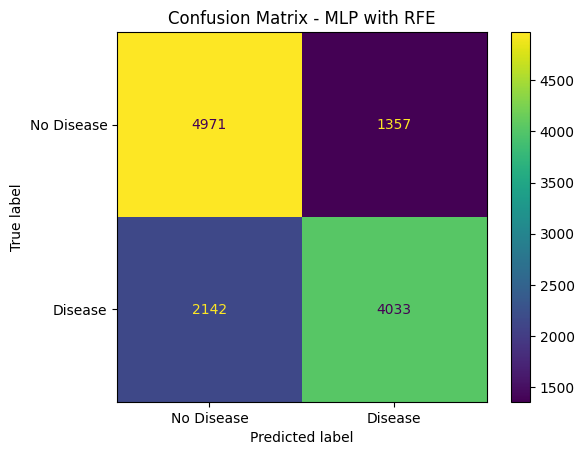

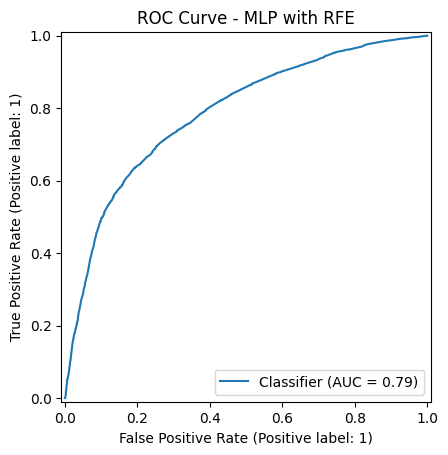

In [22]:
cm = confusion_matrix(N_test, y_test_pred_mlp)
ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"]).plot()
plt.title("Confusion Matrix - MLP with RFE")
plt.show()

RocCurveDisplay.from_predictions(N_test, y_test_prob_mlp)
plt.title("ROC Curve - MLP with RFE")
plt.show()


In [23]:
print("MLP Accuracy Gap:", mlp_train_acc - mlp_test_acc)
print("MLP AUC Gap:", mlp_train_auc - mlp_test_auc)

if (mlp_train_auc - mlp_test_auc) > 0.05:
    print("Possible overfitting detected.")
else:
    print("No major overfitting detected based on AUC gap.")

MLP Accuracy Gap: 0.008447116463294546
MLP AUC Gap: 0.006171209477224382
No major overfitting detected based on AUC gap.


In [25]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

mlp_cv_scores = cross_val_score(
    mlp,
    M_train_rfe,
    N_train,
    cv=cv,
    scoring="roc_auc"
)

print("MLP CV AUC scores:", mlp_cv_scores)
print("Mean CV AUC:", mlp_cv_scores.mean())
print("CV Standard Deviation:", mlp_cv_scores.std())

MLP CV AUC scores: [0.78818176 0.79297398 0.79016019]
Mean CV AUC: 0.7904386425458094
CV Standard Deviation: 0.0019662968181476167


## Interpretablity techniques ##

MLP XAI 1 — Permutation Importance

In [28]:

mlp_perm = permutation_importance(
    mlp,
    M_test_rfe,
    N_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

mlp_importance_df = pd.DataFrame({
    "Feature": rfe_features,
    "Importance": mlp_perm.importances_mean
}).sort_values(by="Importance", ascending=False)

mlp_importance_df

,Feature,Importance
1,AP_HIGH,0.059472
7,AGE_BP_RISK,0.028523
3,CHOLESTEROL,0.017596
0,AGE,0.011446
5,MAP,0.006258
4,PULSE_PRESSURE,0.004615
2,AP_LOW,0.004615
6,RISK_SCORE,0.002827


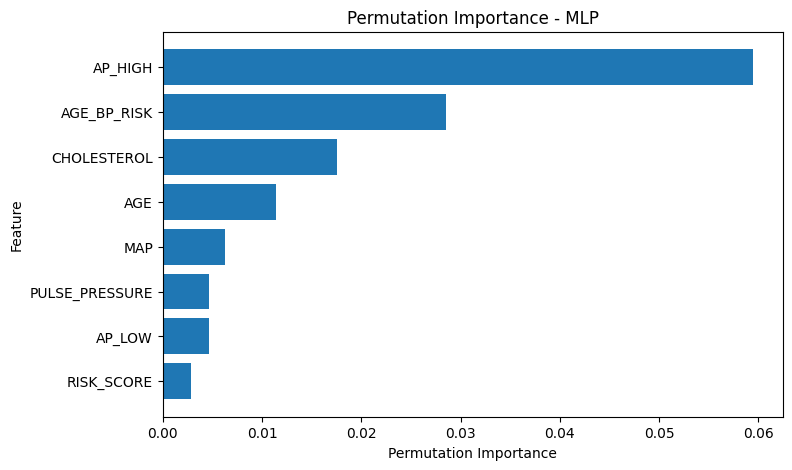

In [29]:
plt.figure(figsize=(8, 5))
plt.barh(mlp_importance_df["Feature"], mlp_importance_df["Importance"])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Permutation Importance - MLP")
plt.gca().invert_yaxis()
plt.show()

MLP XAI 2 — SHAP Summary Plot

In [ ]:
# !pip install shap -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Sigma\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


100%|██████████| 100/100 [00:01<00:00, 56.06it/s]


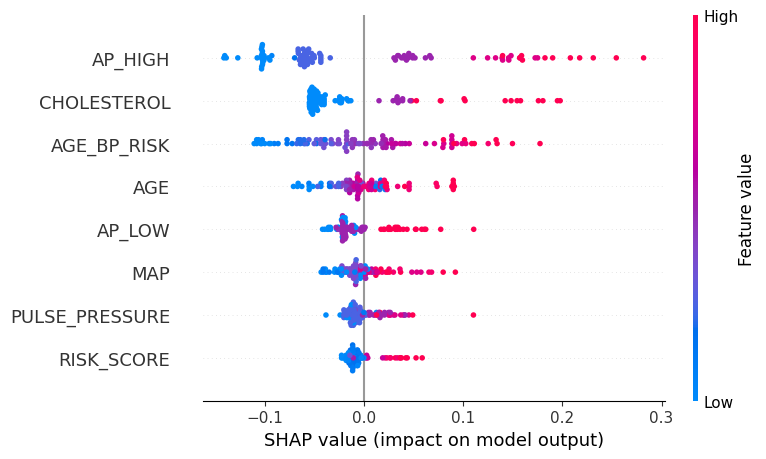

In [32]:
import shap

# Small background and test sample to keep Kernel SHAP fast
background = shap.sample(M_train_rfe, 100, random_state=42)
X_test_rfe_sample = M_test_rfe[:100]

# Pass a single-output function (P(class=1)) so shap_values is a plain 2D array
mlp_shap_explainer = shap.KernelExplainer(
    lambda x: mlp.predict_proba(x)[:, 1], background
)
mlp_shap_values = mlp_shap_explainer.shap_values(X_test_rfe_sample)

shap.summary_plot(
    mlp_shap_values,
    X_test_rfe_sample,
    feature_names=rfe_features
)


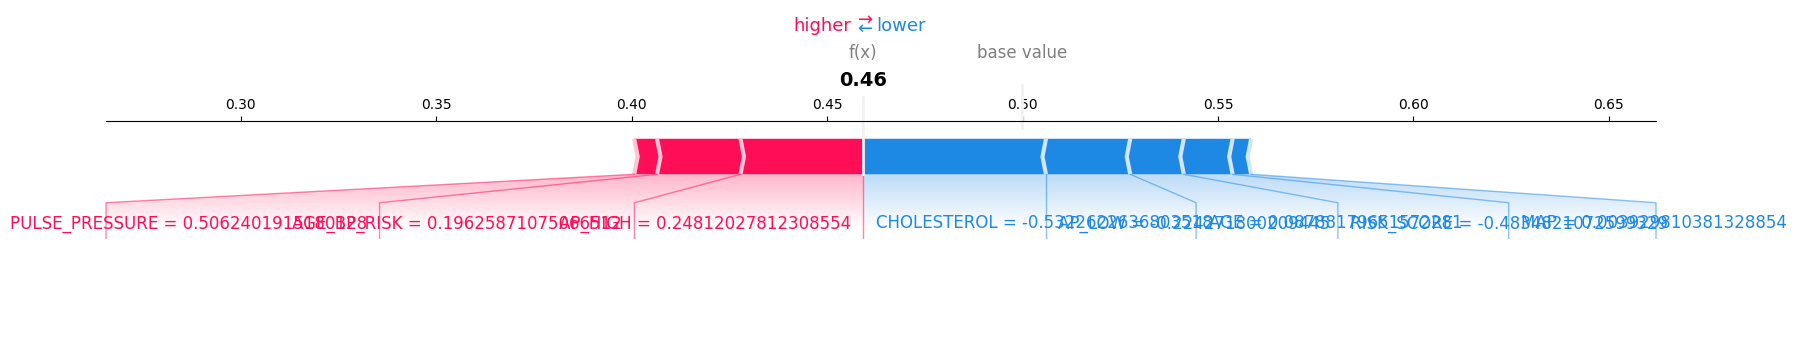

In [34]:
sample_index = 0

shap.force_plot(
    mlp_shap_explainer.expected_value,
    mlp_shap_values[sample_index],
    X_test_rfe_sample[sample_index],
    feature_names=rfe_features,
    matplotlib=True
)
plt.show()


MLP XAI 3 — LIME Local Explanation

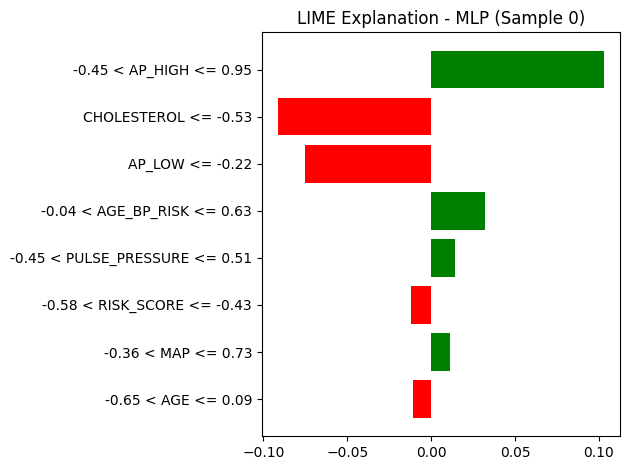

In [36]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=M_train_rfe,
    feature_names=rfe_features,
    class_names=["No Disease", "Disease"],
    mode="classification",
    random_state=42
)

sample_index = 0
lime_exp = lime_explainer.explain_instance(
    M_test_rfe[sample_index],
    mlp.predict_proba,
    num_features=len(rfe_features)
)

fig = lime_exp.as_pyplot_figure()
plt.title("LIME Explanation - MLP (Sample 0)")
plt.tight_layout()
plt.show()


MLP XAI 4 — PDP / ICE Plot

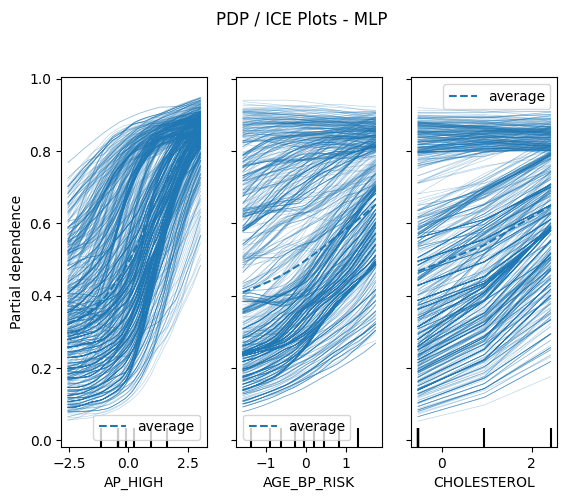

In [37]:
top_mlp_features = mlp_importance_df["Feature"].head(3).tolist()
top_mlp_indices = [rfe_features.index(feature) for feature in top_mlp_features]

PartialDependenceDisplay.from_estimator(
    mlp,
    M_test_rfe,
    features=top_mlp_indices,
    feature_names=rfe_features,
    kind="both"
)
plt.suptitle("PDP / ICE Plots - MLP", y=1.02)
plt.show()